# 📌 Optimizer Comparison: SGD, Mini-Batch GD, Full-Batch GD, Momentum, RMSprop, Adam

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

# ✅ Load the Housing Dataset

In [3]:
url = "https://raw.githubusercontent.com/Phionanamugga/teaching/refs/heads/main/datasets/housing.csv"
df = pd.read_csv(url)

# ✅ Prepare Features (X) and Target (y)

In [4]:
X = df.iloc[:, :-1].values  # Features (all columns except the last)
y = df.iloc[:, -1].values   # Target variable (last column)

# ✅ Split into Training & Test Sets

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ✅ Normalize Features (Gradient Descent is sensitive to scaling)

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ✅ Add Bias Term (X0 = 1) for Intercept

In [7]:
X_train_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

# 🔹 1️⃣ FULL-BATCH GRADIENT DESCENT 🔹

In [8]:
def full_batch_gd(X, y, learning_rate=0.01, epochs=1000):
    m, n = X.shape
    theta = np.random.randn(n)  
    cost_history = []

    for epoch in range(epochs):
        gradients = 2 / m * X.T @ (X @ theta - y)
        theta -= learning_rate * gradients
        cost_history.append(mean_squared_error(y, X @ theta))

    return theta, cost_history

# 🔹 2️⃣ MINI-BATCH GRADIENT DESCENT 🔹

In [9]:
def mini_batch_gd(X, y, learning_rate=0.01, epochs=1000, batch_size=32):
    m, n = X.shape
    theta = np.random.randn(n)  
    cost_history = []

    for epoch in range(epochs):
        shuffled_indices = np.random.permutation(m)  
        X_shuffled, y_shuffled = X[shuffled_indices], y[shuffled_indices]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            gradients = 2 / batch_size * X_batch.T @ (X_batch @ theta - y_batch)
            theta -= learning_rate * gradients

        cost_history.append(mean_squared_error(y, X @ theta))

    return theta, cost_history

# 🔹 3️⃣ STOCHASTIC GRADIENT DESCENT 🔹

In [10]:
def stochastic_gd(X, y, learning_rate=0.01, epochs=1000):
    m, n = X.shape
    theta = np.random.randn(n)  
    cost_history = []

    for epoch in range(epochs):
        for i in range(m):
            random_index = np.random.randint(m)
            xi, yi = X[random_index:random_index+1], y[random_index:random_index+1]

            gradients = 2 * xi.T @ (xi @ theta - yi)
            theta -= learning_rate * gradients

        cost_history.append(mean_squared_error(y, X @ theta))

    return theta, cost_history


# 🔹 4️⃣ MOMENTUM OPTIMIZATION 🔹

In [11]:
def momentum_gd(X, y, learning_rate=0.01, epochs=1000, beta=0.9):
    m, n = X.shape
    theta = np.random.randn(n)  
    v = np.zeros(n)  
    cost_history = []

    for epoch in range(epochs):
        gradients = 2 / m * X.T @ (X @ theta - y)
        v = beta * v + (1 - beta) * gradients  
        theta -= learning_rate * v

        cost_history.append(mean_squared_error(y, X @ theta))

    return theta, cost_history

# 🔹 5️⃣ RMSprop OPTIMIZATION 🔹

In [12]:
def rmsprop_gd(X, y, learning_rate=0.01, epochs=1000, beta=0.9, epsilon=1e-8):
    m, n = X.shape
    theta = np.random.randn(n)  
    s = np.zeros(n)  
    cost_history = []

    for epoch in range(epochs):
        gradients = 2 / m * X.T @ (X @ theta - y)
        s = beta * s + (1 - beta) * (gradients ** 2)  
        theta -= learning_rate * gradients / (np.sqrt(s) + epsilon)

        cost_history.append(mean_squared_error(y, X @ theta))

    return theta, cost_history

# 🔹 6️⃣ ADAM OPTIMIZATION 🔹

In [13]:
def adam_gd(X, y, learning_rate=0.01, epochs=1000, beta1=0.9, beta2=0.999, epsilon=1e-8):
    m, n = X.shape
    theta = np.random.randn(n)  
    v, s = np.zeros(n), np.zeros(n)  
    cost_history = []

    for epoch in range(epochs):
        gradients = 2 / m * X.T @ (X @ theta - y)

        v = beta1 * v + (1 - beta1) * gradients  
        s = beta2 * s + (1 - beta2) * (gradients ** 2)  

        v_corrected = v / (1 - beta1 ** (epoch + 1))
        s_corrected = s / (1 - beta2 ** (epoch + 1))

        theta -= learning_rate * v_corrected / (np.sqrt(s_corrected) + epsilon)

        cost_history.append(mean_squared_error(y, X @ theta))

    return theta, cost_history

# ✅ Run all optimizers

In [14]:
optimizers = {
    "Full-Batch GD": full_batch_gd,
    "Mini-Batch GD": mini_batch_gd,
    "Stochastic GD": stochastic_gd,
    "Momentum GD": momentum_gd,
    "RMSprop GD": rmsprop_gd,
    "Adam GD": adam_gd
}

results = {}

for name, optimizer in optimizers.items():
    print(f"Running {name}...")
    theta, cost_history = optimizer(X_train_b, y_train)
    results[name] = (theta, cost_history)

Running Full-Batch GD...
Running Mini-Batch GD...
Running Stochastic GD...
Running Momentum GD...
Running RMSprop GD...
Running Adam GD...


# ✅ Compare Models on Test Data

In [15]:
for name, (theta, _) in results.items():
    y_pred = X_test_b @ theta
    mse = mean_squared_error(y_test, y_pred)
    print(f"{name} MSE: {mse:.4f}")

Full-Batch GD MSE: 0.1603
Mini-Batch GD MSE: 0.1473
Stochastic GD MSE: 0.2087
Momentum GD MSE: 0.1474
RMSprop GD MSE: 0.1489
Adam GD MSE: 0.1571


# ✅ Visualization: Loss Reduction Comparison

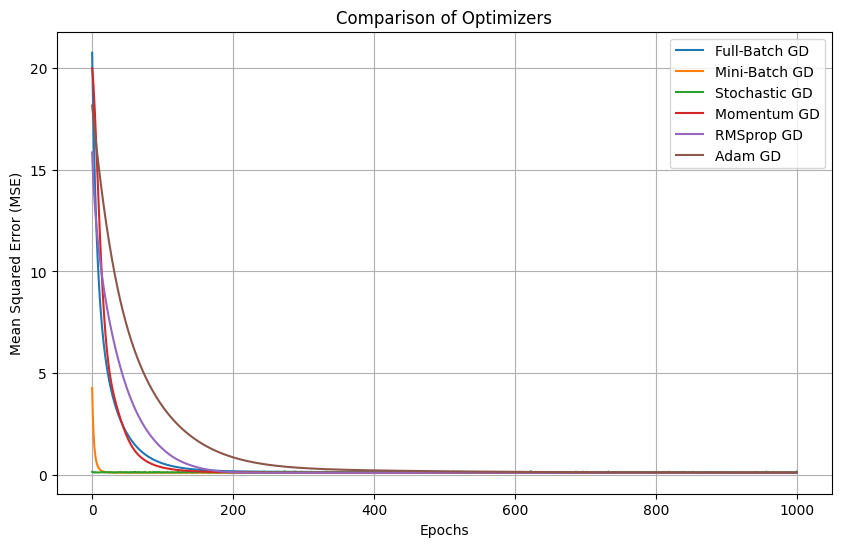

In [16]:
plt.figure(figsize=(10,6))
for name, (_, cost_history) in results.items():
    plt.plot(cost_history, label=name)

plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Comparison of Optimizers")
plt.legend()
plt.grid()
plt.show()